# Uses & information content — MN/TSRV

What Êε² / noise_std / fifth–fourth / TSRV−sparse co-move with, and how the desk should use clocks & monitors.

**SoT:** [`../TRADING_APPLICATIONS.md`](../TRADING_APPLICATIONS.md) · [`../DESK_MEMO.md`](../DESK_MEMO.md) · `out/depth_predict/`


In [1]:
from pathlib import Path
import os
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = (Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # ares-microstructure root

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
ep = jload('expand_panel/expand_panel.json')
dp = jload('depth_predict/depth_predict.json') if (OUT/'depth_predict'/'depth_predict.json').exists() else {}
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))
print('expand n_ok', ep['coverage']['n_ok'], 'depth keys', list(dp.keys())[:8])


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_info_heatmap.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_acf_lag1.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_pred_board.png', 'fig_pred_ic_noise.png', 'fig_ratio_hist.png', 'fig_signature.png', 'fig_tob_coverage.png', 'fig_tod_acf.png', 'fig_tsrv_oos.png', 'fig_venue_mid_taxonomy.png', 'signal_board.png']
expand n_ok 204 depth keys ['meta', 'information', 'predictive', 'taxonomy', 'tape_depth', 'uses', 'figures', 'decisions_rollup']


## 1. Information matrix


**Spearman information heatmap** — `out/desk_synthesis/figs/fig_info_heatmap.png`

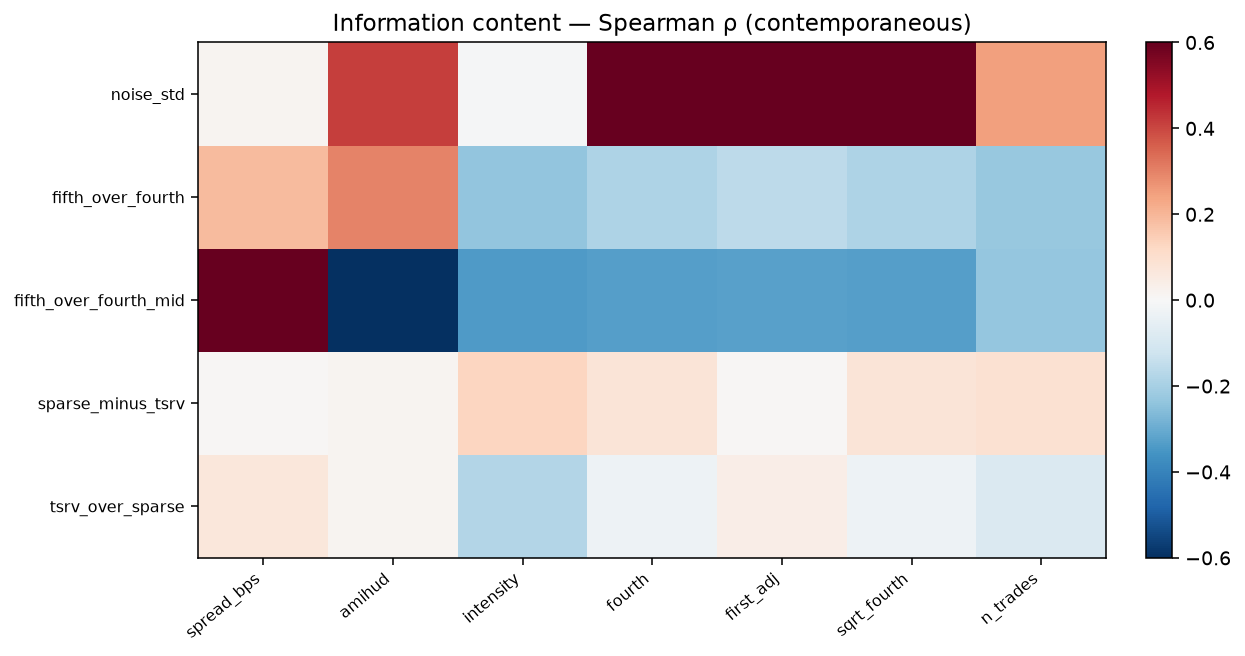

n 204

== noise_std


,n,rho,lo,hi,shuffle_p
spread_bps,144.0,0.016405,-0.163259,0.190791,0.8475
amihud,204.0,0.413934,0.312555,0.508768,0.0000
intensity,204.0,-0.008550,-0.127586,0.128315,0.9050
fourth,204.0,0.765013,0.691822,0.823472,0.0000
first_adj,204.0,0.764005,0.689614,0.824886,0.0000
sqrt_fourth,204.0,0.765013,0.691073,0.826359,0.0000
n_trades,204.0,0.246807,0.106533,0.366598,0.0000



== fifth_over_fourth


,n,rho,lo,hi,shuffle_p
spread_bps,144.0,0.188100,0.014251,0.359435,0.0375
amihud,204.0,0.296696,0.180837,0.411721,0.0000
intensity,204.0,-0.235277,-0.366183,-0.095195,0.0000
fourth,204.0,-0.184940,-0.320267,-0.049427,0.0125
first_adj,204.0,-0.159002,-0.292060,-0.024375,0.0400
sqrt_fourth,204.0,-0.184940,-0.320835,-0.050963,0.0075
n_trades,204.0,-0.227319,-0.359614,-0.093942,0.0000



== fifth_over_fourth_mid


...

,n,rho,lo,hi,shuffle_p
spread_bps,144.0,0.009143,-0.144250,0.144308,0.9200
amihud,204.0,0.014168,-0.133234,0.163648,0.8575
intensity,204.0,0.128432,-0.012920,0.272372,0.0750
fourth,204.0,0.076532,-0.087610,0.234455,0.3100
first_adj,204.0,0.005558,-0.152068,0.179800,0.9325
sqrt_fourth,204.0,0.076532,-0.106036,0.240507,0.3150
n_trades,204.0,0.089302,-0.059804,0.227843,0.2075



== tsrv_over_sparse


,n,rho,lo,hi,shuffle_p
spread_bps,144.0,0.069363,-0.108616,0.248396,0.4050
amihud,204.0,0.016155,-0.125583,0.153192,0.7950
intensity,204.0,-0.176611,-0.303600,-0.043780,0.0125
fourth,204.0,-0.029061,-0.174002,0.118312,0.6800
first_adj,204.0,0.041707,-0.114906,0.188660,0.5325
sqrt_fourth,204.0,-0.029061,-0.181550,0.126956,0.6925
n_trades,204.0,-0.087316,-0.229200,0.059257,0.2350



interpretation: Pass 2.7 already Hold on noise↔spread (ρ≈0). Recompute here on full stack; do not Promote friction claim without CI_lo>0.


,n,rho,lo,hi,shuffle_p
noise_vs_spread,144.0,0.016405,-0.163259,0.190791,0.8475
noise_vs_amihud,204.0,0.413934,0.312555,0.508768,0.0000
noise_vs_intensity,204.0,-0.008550,-0.127586,0.128315,0.9050
noise_vs_sparse_rv,204.0,0.765013,0.691822,0.823472,0.0000


In [2]:
show_fig('fig_info_heatmap.png', 'Spearman information heatmap')
info = dp['information']
print('n', info['n'])
for pred, tgts in info['matrix'].items():
    print('\n==', pred)
    display(pd.DataFrame(tgts).T[['n','rho','lo','hi','shuffle_p']])
print('\ninterpretation:', info['interpretation']['read'])
display(pd.DataFrame(info['interpretation']['observed']).T)


## 2. Regime splits


In [3]:
info = dp['information']
for name, reg in info['regimes'].items():
    print(name, json.dumps(reg, indent=2)[:500])


intensity {
  "ok": true,
  "median_split": 0.870430065537326,
  "high": {
    "n": 67.0,
    "rho": 0.47190517998244075,
    "lo": 0.22810878761273845,
    "hi": 0.6685759039029452
  },
  "low": {
    "n": 77.0,
    "rho": -0.3265418791734581,
    "lo": -0.5383991008991009,
    "hi": -0.12157382091592638
  },
  "note": "noise\u2194spread in high/low intensity; noise\u2194intensity in high/low spread"
}
spread {
  "ok": true,
  "median_split": 3.1712032717471375,
  "high": {
    "n": 72.0,
    "rho": 0.16698823075438934,
    "lo": -0.11055534117949706,
    "hi": 0.42191057302720425
  },
  "low": {
    "n": 72.0,
    "rho": -0.24561065020258538,
    "lo": -0.44656569554312175,
    "hi": -0.02991912663193776
  },
  "note": "noise\u2194spread in high/low intensity; noise\u2194intensity in high/low spread"
}


## 3. Venue / symbol taxonomy


**Mid-clock by venue** — `out/desk_synthesis/figs/fig_venue_mid_taxonomy.png`

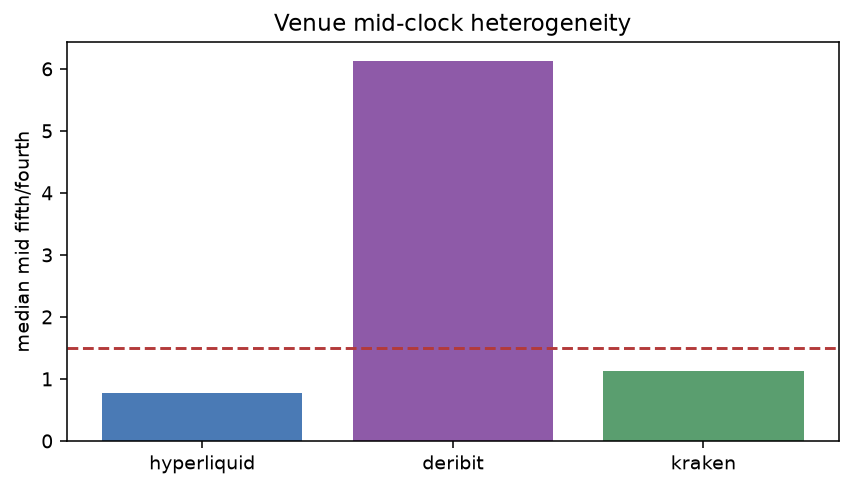

,n,median,p25,p75
hyperliquid,33.0,0.770559,0.697910,0.970031
deribit,82.0,6.118724,1.372974,15.415358
kraken,7.0,1.130437,1.049945,1.945790


,n,noise_std_med,fifth_fourth_cal_med,fifth_fourth_mid_med,n_mid,sparse_minus_tsrv_med
hyperliquid|SOL,1.0,0.000152,0.807486,0.738743,1.0,7.949831e-05
deribit|SOL,34.0,0.000072,1.126245,1.002643,21.0,-7.459540e-07
hyperliquid|ETH,34.0,0.000058,0.974279,0.858845,16.0,1.931643e-06
kraken|SOL,11.0,0.000057,1.384801,NaN,0.0,-2.451779e-06
deribit|ETH,34.0,0.000052,0.942418,11.421912,31.0,-2.645313e-06
hyperliquid|BTC,34.0,0.000043,0.881542,0.729892,16.0,2.571363e-06
deribit|BTC,34.0,0.000038,0.963145,8.430527,30.0,-1.691727e-07
kraken|ETH,11.0,0.000035,1.224050,1.491308,4.0,3.534369e-06
kraken|BTC,11.0,0.000032,0.984773,1.047923,3.0,1.426384e-06


In [4]:
show_fig('fig_venue_mid_taxonomy.png', 'Mid-clock by venue')
tax = dp['taxonomy']
display(pd.DataFrame(tax['venue_mid']).T)
display(pd.DataFrame(tax['cells']).T.sort_values('noise_std_med', ascending=False).head(12))


## 4. Thesis diagnostics


**Signature** — `out/desk_synthesis/figs/fig_signature.png`

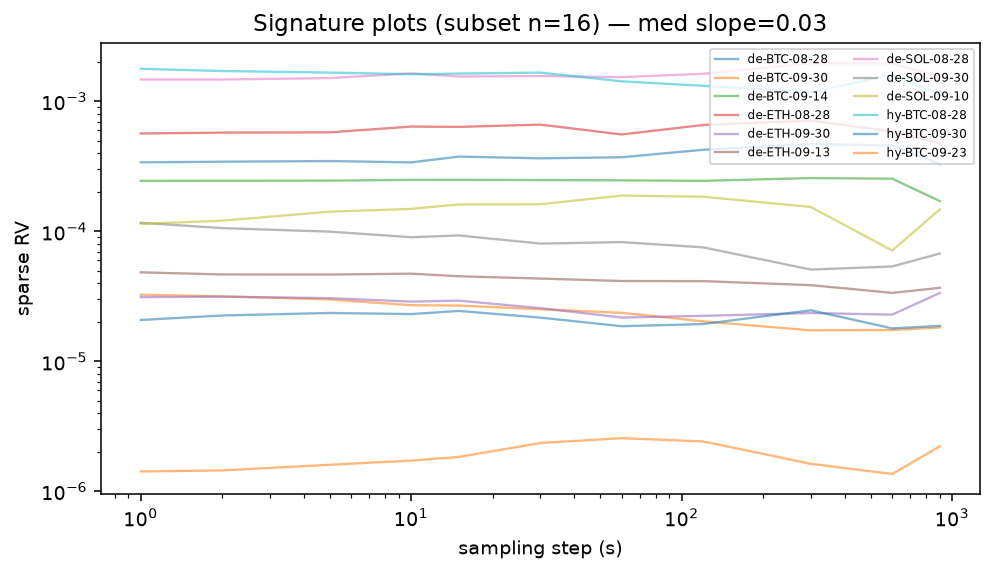

**Noise ACF** — `out/desk_synthesis/figs/fig_noise_acf_lag1.png`

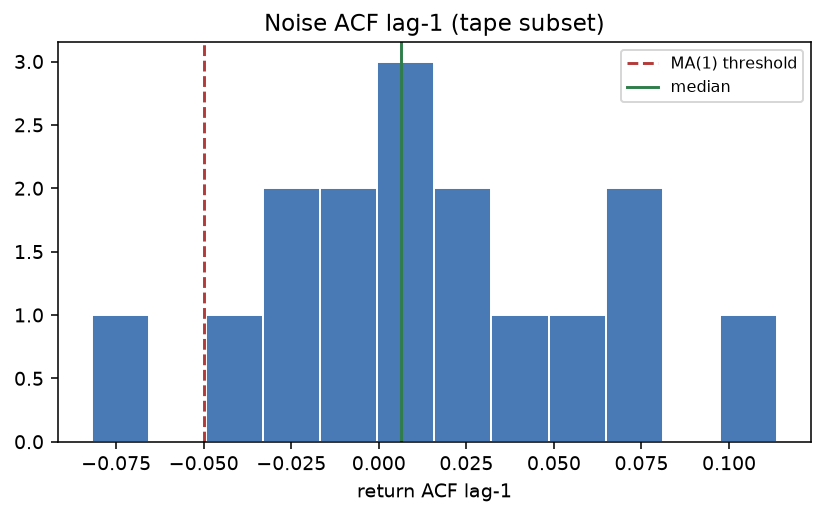

**TOD** — `out/desk_synthesis/figs/fig_tod_acf.png`

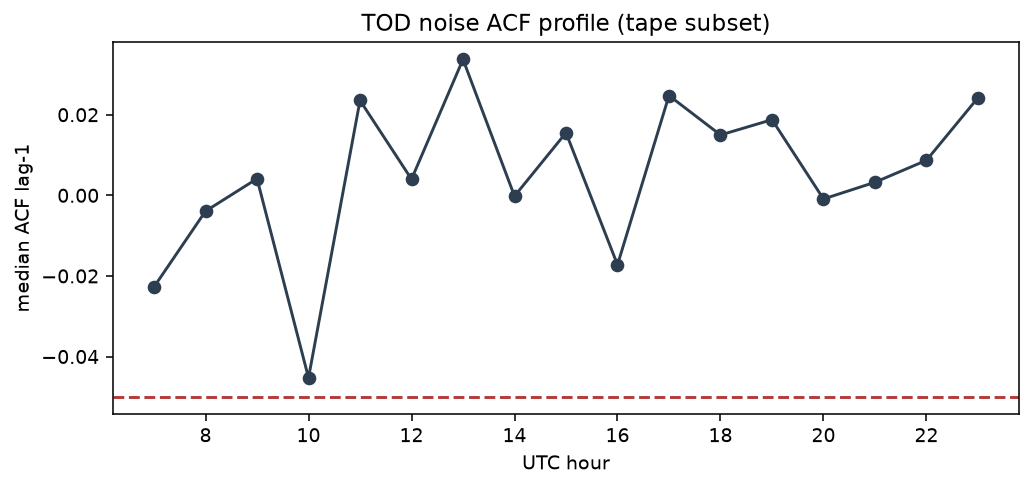

{
  "signature": {
    "median_fine_log_slope": 0.029292820592576027,
    "frac_negative_slope": 0.3125,
    "note": "Negative fine-end log(RV)/log(step) slope \u21d2 noise-dominated high-freq RV (thesis signature)"
  },
  "noise_acf": {
    "median_lag1": 0.006424349386435315,
    "frac_ma1_compatible": 0.0625,
    "note": "ZMA05 i.i.d. noise \u21d2 negative lag-1 return ACF (MA(1)-like)"
  },
  "optimal_K": {
    "median_best_K": 180.0,
    "book_default_K": 300,
    "note": "Stability proxy vs median first_adj \u2014 not true IV oracle"
  }
}


In [5]:
show_fig('fig_signature.png', 'Signature')
show_fig('fig_noise_acf_lag1.png', 'Noise ACF')
show_fig('fig_tod_acf.png', 'TOD')
td = dp['tape_depth']
print(json.dumps({k: {kk: vv for kk, vv in td.get(k, {}).items() if kk != 'rows'} for k in ('signature','noise_acf','optimal_K')}, indent=2))


## 5. Trading applications / monitors


In [6]:
uses = dp['uses']
print('TSRV vs sparse:', uses['when_prefer_tsrv_vs_sparse'])
print('mid-clock:', uses['when_mid_clock_noise_matters']['quoting'])
print('clock trust:', uses['clock_trust'])
display(pd.DataFrame(uses['monitors']))
ideas = jload('depth_predict/trade_ideas.json')
display(pd.DataFrame(ideas['ideas']))
# thin monitor snapshot
import importlib.util
spec = importlib.util.spec_from_file_location('mon', BOOK/'applications'/'monitors.py')
mon = importlib.util.module_from_spec(spec); spec.loader.exec_module(mon)
snap = mon.run_latest_snapshot()
print('monitor alerts', snap.get('n_alerts'), 'path', snap.get('path'))


TSRV vs sparse: {'risk_RV': 'Always prefer TSRV/first_adj over sparse-only for risk RV — MC Kill stands regardless of tape OOS Hold.', 'tape_advantage': 'DM late OOS prefer=sparse t=-1.997244766311049 — do not size a tradable TSRV edge; use as bias-reduced RV input.', 'confidence': 'high for MC policy; med for tape DM'}
mid-clock: Mid-clock fifth/fourth elevated (esp. Deribit) ⇒ bounce on mid path; widen / distrust mid-mark RV; calendar/trade clocks do NOT show bounce domination (Kill).
clock trust: {'calendar': 'Kill as bounce-domination claim; still default sampling clock for TSRV.', 'trade': 'Kill — fifth/fourth < 1.', 'tick_bounce': 'Kill — CI fails gate.', 'mid': 'Hold — point estimate high, CI_lo < 1.5; Deribit≫HL.', 'ops': 'Publish clock alongside RV; never treat trade-clock bounce as Promote.'}


,id,spec,action,conf
0,mon.noise_std_level,rolling venue-day noise_std vs 14d median; fla...,research/risk strip — not auto-widen until liq...,low
1,mon.mid_fifth_fourth,when quoted TOB: mid fifth/fourth; alert if >3...,MM: treat mid-mark vol as noisy; prefer TSRV o...,med
2,mon.tsrv_sparse_gap,sparse−first_adj; alert if gap widens vs own 14d,risk: prefer first_adj for σ budgets when gap ...,med
3,mon.signature_slope,fine log-slope med=0.029292820592576027,diagnostic that 1s RV is noise-dominated — Kil...,high
4,mon.acf_lag1,return ACF lag1 med=0.006424349386435315,MA(1) noise check; if lag1≳0 revisit i.i.d. no...,med


,id,kind,spec,action,conf,pnl_claim
0,mon.noise_std_level,monitor,rolling venue-day noise_std vs 14d median; fla...,research/risk strip — not auto-widen until liq...,low,False
1,mon.mid_fifth_fourth,monitor,when quoted TOB: mid fifth/fourth; alert if >3...,MM: treat mid-mark vol as noisy; prefer TSRV o...,med,False
2,mon.tsrv_sparse_gap,monitor,sparse−first_adj; alert if gap widens vs own 14d,risk: prefer first_adj for σ budgets when gap ...,med,False
3,mon.signature_slope,monitor,fine log-slope med=0.029292820592576027,diagnostic that 1s RV is noise-dominated — Kil...,high,False
4,mon.acf_lag1,monitor,return ACF lag1 med=0.006424349386435315,MA(1) noise check; if lag1≳0 revisit i.i.d. no...,med,False


monitor alerts 3 path /home/dev/srv/ares-microstructure/research/books/mn_tuwrv/applications/out/monitor_snapshot.json
